# Exp 5: IVM Symmetric Hash Join (TPC-H PART ⟕ LINEITEM)

Multi-threaded IVM benchmark: concurrent reader (probe) + writer (update) threads.

Compares: **SNAP, MONO-NR/RR/WR, DUAL-WR, EPOCH-NR/RR/WR**

Three sub-experiments:
- **5a**: Throughput vs reader threads (scalability)
- **5b**: Total time (fixed workload, varying table type)
- **5c**: Throughput vs update rate

**Run all cells top-to-bottom.**

In [28]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'matplotlib'])
print('done')

done



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from pathlib import Path
import subprocess, os, sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

ROOT      = Path('../../').resolve()
EXP5_DIR  = (ROOT / 'benches' / 'exp5_ivm_join').resolve()
DATA_DIR  = EXP5_DIR / 'data'
TPCH_DIR  = (ROOT / 'benches' / 'sigmod' / 'tpch_data').resolve()
BIN       = ROOT / 'target' / 'release' / 'ivm_bench'

DATA_DIR.mkdir(parents=True, exist_ok=True)
(EXP5_DIR / 'figs').mkdir(parents=True, exist_ok=True)

# ===== CONFIG =====
SF          = '1.0'
BUCKET_NUM  = 2048
WARMUP      = 1
REPEAT      = 5
TRIM        = 1

PART_FILE     = TPCH_DIR / f'part_sf{SF}.tbl'
LINEITEM_FILE = TPCH_DIR / f'lineitem_probe_sf{SF}_1995-09-01_1995-10-01.tbl'

# Update configs
UPDATE_PCT  = 1       # default update percent for scalability test
DIST        = 'uniform'
UPDATES_FILE = TPCH_DIR / f'part_updates_sf{SF}_{UPDATE_PCT}pct_{DIST}.tbl'

# All MVCC series: (table_type, repair_mode)
SERIES = [
    ('heap',  'nr'), ('heap',  'rr'), ('heap',  'wr'),
    ('chain', 'wr'),
    ('par',   'nr'), ('par',   'rr'), ('par',   'wr'),
]

# Paul Tol Bright palette
tol = {
    'blue':   '#4477AA',
    'cyan':   '#66CCEE',
    'green':  '#228833',
    'yellow': '#CCBB44',
    'red':    '#EE6677',
    'purple': '#AA3377',
    'grey':   '#BBBBBB',
}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif']

print('ROOT       :', ROOT)
print('PART       :', PART_FILE)
print('LINEITEM   :', LINEITEM_FILE)
print('UPDATES    :', UPDATES_FILE)

ROOT       : .
PART       : ./benches/sigmod/tpch_data/part_sf1.tbl
LINEITEM   : ./benches/sigmod/tpch_data/lineitem_probe_sf1_1995-09-01_1995-10-01.tbl
UPDATES    : ./benches/sigmod/tpch_data/part_updates_sf1_1pct_uniform.tbl


In [30]:
# ── Build Rust binary ──────────────────────────────────────────────────────
print('Building ivm_bench...')
result = subprocess.run(
    ['cargo', 'build', '--release', '--bin', 'ivm_bench'],
    cwd=ROOT, capture_output=True, text=True,
)
if result.returncode != 0:
    print('STDERR:', result.stderr[-2000:])
    raise RuntimeError('cargo build failed')
print('Build OK')

Building ivm_bench...
Build OK


In [31]:
# ── Verify data files ──────────────────────────────────────────────────────
for f in [PART_FILE, LINEITEM_FILE, UPDATES_FILE]:
    if not f.exists():
        raise FileNotFoundError(f'Missing: {f}')
    rows = sum(1 for _ in open(f))
    print(f'  {f.name}: {rows:,} rows')

FileNotFoundError: Missing: ./benches/sigmod/tpch_data/part_sf1.tbl

In [ ]:
# ── Helper: run ivm_bench ──────────────────────────────────────────────────
def run_ivm(table_type, repair_mode, reader_threads, writer_threads,
            updates_file, output_csv, extra_args=None):
    cmd = [
        str(BIN),
        '--part-file',      str(PART_FILE),
        '--lineitem-file',  str(LINEITEM_FILE),
        '--updates-file',   str(updates_file),
        '--table-type',     table_type,
        '--repair-mode',    repair_mode,
        '--bucket-num',     str(BUCKET_NUM),
        '--reader-threads', str(reader_threads),
        '--writer-threads', str(writer_threads),
        '--warmup',         str(WARMUP),
        '--repeat',         str(REPEAT),
        '--trim',           str(TRIM),
        '--output-csv',     str(output_csv),
    ]
    if extra_args:
        cmd.extend(extra_args)
    r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  FAILED: {r.stderr[:400]}')
        return False
    # Print summary line
    for line in r.stderr.strip().split('\n'):
        if 'Average' in line or 'total_ms' in line or 'read_tput' in line:
            print(f'  {line.strip()}')
    return True

---
## Exp 5a: Throughput vs Reader Threads (Scalability)

Fixed 1 writer thread, sweep reader threads from 1 to N.

In [ ]:
# ── Exp 5a: Scalability ────────────────────────────────────────────────────
READER_COUNTS = [1, 2, 4, 8]
WRITER_THREADS_5A = 1

CSV_5A = DATA_DIR / f'exp5a_scalability_sf{SF}_{UPDATE_PCT}pct_{DIST}.csv'

if CSV_5A.exists():
    CSV_5A.unlink()
    print('Removed old CSV')

# Also run SNAP baseline
all_series_5a = [('snap', 'nr')] + SERIES
total_runs = len(all_series_5a) * len(READER_COUNTS)
current = 0

for n_readers in READER_COUNTS:
    for (ttype, rmode) in all_series_5a:
        current += 1
        wt = 0 if ttype == 'snap' else WRITER_THREADS_5A
        print(f'[{current}/{total_runs}] readers={n_readers} table={ttype} repair={rmode}')
        run_ivm(ttype, rmode, n_readers, wt, UPDATES_FILE, CSV_5A)

print(f'\nDone. Results -> {CSV_5A}')

Removed old CSV
[1/32] readers=1 table=snap repair=nr
  [iter 1] total=7.6ms  read_tput=1006016 ops/s  write_tput=0 ops/s
  [iter 2] total=10.7ms  read_tput=712906 ops/s  write_tput=0 ops/s
  [iter 3] total=10.6ms  read_tput=720647 ops/s  write_tput=0 ops/s
  [iter 4] total=8.9ms  read_tput=860441 ops/s  write_tput=0 ops/s
  [iter 5] total=7.9ms  read_tput=966628 ops/s  write_tput=0 ops/s
  === Average (trimmed) ===
  total_ms:    9.1
  read_tput:   849239 ops/s
[2/32] readers=1 table=heap repair=nr
  [iter 1] total=3.1ms  read_tput=2450783 ops/s  write_tput=64241 ops/s
  [iter 2] total=2.8ms  read_tput=2753105 ops/s  write_tput=72165 ops/s
  [iter 3] total=2.4ms  read_tput=3195142 ops/s  write_tput=83752 ops/s
  [iter 4] total=2.4ms  read_tput=3117626 ops/s  write_tput=81720 ops/s
  [iter 5] total=2.3ms  read_tput=3367663 ops/s  write_tput=88274 ops/s
  === Average (trimmed) ===
  total_ms:    2.5
  read_tput:   3021958 ops/s
[3/32] readers=1 table=heap repair=rr
  [iter 1] total=3.7m

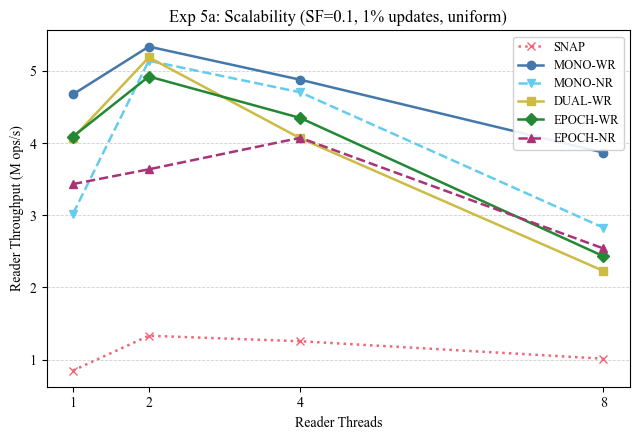

Saved: ./benches/exp5_ivm_join/figs/exp5a_scalability_sf0.1_uniform.pdf


In [ ]:
# ── Plot 5a: Throughput vs Reader Threads ──────────────────────────────────
df5a = pd.read_csv(CSV_5A)

# Normalize names
tmap  = {'Heap': 'heap', 'Chain': 'chain', 'Par': 'par', 'Snap': 'snap'}
rmap  = {'Nr': 'NR', 'Rr': 'RR', 'Wr': 'WR'}
df5a['table']  = df5a['table_type'].map(tmap).fillna(df5a['table_type'])
df5a['repair'] = df5a['repair_mode'].map(rmap).fillna(df5a['repair_mode'])

LINES_5A = [
    ('snap',  'NR', 'SNAP',     tol['red'],    ':',  'x'),
    ('heap',  'WR', 'MONO-WR',  tol['blue'],   '-',  'o'),
    ('heap',  'NR', 'MONO-NR',  tol['cyan'],   '--', 'v'),
    ('chain', 'WR', 'DUAL-WR',  tol['yellow'], '-',  's'),
    ('par',   'WR', 'EPOCH-WR', tol['green'],  '-',  'D'),
    ('par',   'NR', 'EPOCH-NR', tol['purple'], '--', '^'),
]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (t, r, label, color, ls, marker) in LINES_5A:
    rows = df5a[(df5a['table'] == t) & (df5a['repair'] == r)].sort_values('reader_threads')
    if rows.empty:
        continue
    ax.plot(rows['reader_threads'], rows['reader_throughput'] / 1e6,
            label=label, color=color, linestyle=ls, marker=marker,
            linewidth=1.8, markersize=6)

ax.set_xlabel('Reader Threads')
ax.set_ylabel('Reader Throughput (M ops/s)')
ax.set_xticks(READER_COUNTS)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.legend(framealpha=0.9, fontsize=9)
ax.set_title(f'Exp 5a: Scalability (SF={SF}, {UPDATE_PCT}% updates, {DIST})')

plt.tight_layout()
out_pdf = EXP5_DIR / 'figs' / f'exp5a_scalability_sf{SF}_{DIST}.pdf'
plt.savefig(str(out_pdf), format='pdf')
plt.show()
print('Saved:', out_pdf)

---
## Exp 5b: Total Time (Fixed Workload)

Bar chart comparing total completion time for each table type with fixed reader/writer threads.

In [ ]:
# ── Exp 5b: Total time bar chart ──────────────────────────────────────────
READERS_5B = 4
WRITERS_5B = 1

CSV_5B = DATA_DIR / f'exp5b_totaltime_sf{SF}_{UPDATE_PCT}pct_{DIST}.csv'

if CSV_5B.exists():
    CSV_5B.unlink()
    print('Removed old CSV')

all_series_5b = [('snap', 'nr')] + SERIES
total_runs = len(all_series_5b)

for i, (ttype, rmode) in enumerate(all_series_5b):
    wt = 0 if ttype == 'snap' else WRITERS_5B
    print(f'[{i+1}/{total_runs}] table={ttype} repair={rmode}')
    run_ivm(ttype, rmode, READERS_5B, wt, UPDATES_FILE, CSV_5B)

print(f'\nDone. Results -> {CSV_5B}')

Removed old CSV
[1/8] table=snap repair=nr


  [iter 1] total=23.3ms  read_tput=327576 ops/s  write_tput=0 ops/s
  [iter 2] total=29.4ms  read_tput=259592 ops/s  write_tput=0 ops/s
  [iter 3] total=15.9ms  read_tput=479007 ops/s  write_tput=0 ops/s
  [iter 4] total=9.3ms  read_tput=823633 ops/s  write_tput=0 ops/s
  [iter 5] total=6.0ms  read_tput=1271446 ops/s  write_tput=0 ops/s
  === Average (trimmed) ===
  total_ms:    16.2
  read_tput:   543405 ops/s
[2/8] table=heap repair=nr
  [iter 1] total=1.6ms  read_tput=4673576 ops/s  write_tput=122505 ops/s
  [iter 2] total=1.6ms  read_tput=4873453 ops/s  write_tput=127745 ops/s
  [iter 3] total=1.8ms  read_tput=4345927 ops/s  write_tput=113917 ops/s
  [iter 4] total=1.4ms  read_tput=5473458 ops/s  write_tput=143472 ops/s
  [iter 5] total=1.5ms  read_tput=4990872 ops/s  write_tput=130822 ops/s
  === Average (trimmed) ===
  total_ms:    1.6
  read_tput:   4845967 ops/s
[3/8] table=heap repair=rr
  [iter 1] total=2.0ms  read_tput=3877525 ops/s  write_tput=101639 ops/s
  [iter 2] total=

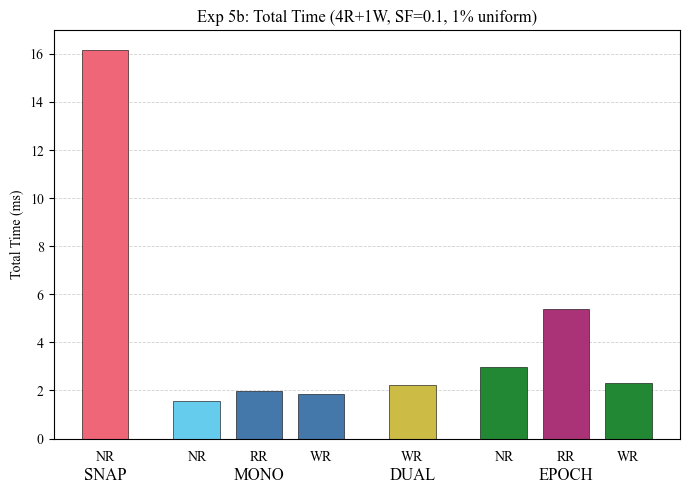

Saved: ./benches/exp5_ivm_join/figs/exp5b_totaltime_sf0.1_uniform.pdf


In [ ]:
# ── Plot 5b: Total time bar chart ─────────────────────────────────────────
df5b = pd.read_csv(CSV_5B)
df5b['table']  = df5b['table_type'].map(tmap).fillna(df5b['table_type'])
df5b['repair'] = df5b['repair_mode'].map(rmap).fillna(df5b['repair_mode'])

table_order   = ['snap', 'heap', 'chain', 'par']
table_display = {'snap': 'SNAP', 'heap': 'MONO', 'chain': 'DUAL', 'par': 'EPOCH'}
repair_order  = {'snap': ['NR'], 'heap': ['NR','RR','WR'], 'chain': ['WR'], 'par': ['NR','RR','WR']}

color_map = {
    ('snap','NR'):  tol['red'],
    ('heap','NR'):  tol['cyan'],   ('heap','RR'):  tol['blue'],   ('heap','WR'):  tol['blue'],
    ('chain','WR'): tol['yellow'],
    ('par','NR'):   tol['green'],  ('par','RR'):   tol['purple'], ('par','WR'):   tol['green'],
}

bar_x, labels, colors, values = [], [], [], []
x = 0.0
bar_w = 0.58
gap   = 0.36
major_centers, major_labels_list = [], []

for t in table_order:
    subs = repair_order[t]
    start = x
    for r in subs:
        row = df5b[(df5b['table'] == t) & (df5b['repair'] == r)]
        if row.empty:
            continue
        bar_x.append(x)
        labels.append(r)
        colors.append(color_map.get((t, r), tol['grey']))
        values.append(float(row.iloc[0]['total_ms']))
        x += 0.78
    end = x - 0.78
    major_centers.append((start + end) / 2.0)
    major_labels_list.append(table_display[t])
    x += gap

fig, ax = plt.subplots(figsize=(7.0, 5.0))
fig.subplots_adjust(bottom=0.18)

ax.bar(bar_x, values, width=bar_w, color=colors, edgecolor='black', linewidth=0.4, zorder=2)

ax.set_xticks([])
for xi, lab in zip(bar_x, labels):
    ax.text(xi, -0.028, lab, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=10, clip_on=False)
for xc, lab in zip(major_centers, major_labels_list):
    ax.text(xc, -0.072, lab, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=12, clip_on=False)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_ylabel('Total Time (ms)')
ax.set_title(f'Exp 5b: Total Time ({READERS_5B}R+{WRITERS_5B}W, SF={SF}, {UPDATE_PCT}% {DIST})')

plt.tight_layout()
out_pdf = EXP5_DIR / 'figs' / f'exp5b_totaltime_sf{SF}_{DIST}.pdf'
plt.savefig(str(out_pdf), format='pdf')
plt.show()
print('Saved:', out_pdf)

---
## Exp 5c: Throughput vs Update Rate

Sweep update percentage with fixed thread count.

In [ ]:
# ── Generate update files for sweep ────────────────────────────────────────
GEN_UPD    = ROOT / 'benches' / 'sigmod' / 'generate_updates.py'
SWEEP_PCTS = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

update_files = {}
for pct in SWEEP_PCTS:
    pct_label = f'{pct:g}'
    if pct == 0:
        uf = TPCH_DIR / f'part_updates_sf{SF}_0pct_empty.tbl'
        if not uf.exists():
            uf.touch()
            print(f'  0% -> empty file created')
        else:
            print(f'  0% exists')
    else:
        uf = TPCH_DIR / f'part_updates_sf{SF}_{pct_label}pct_{DIST}.tbl'
        if not uf.exists():
            print(f'  Generating {pct_label}% updates...')
            r = subprocess.run(
                [sys.executable, str(GEN_UPD),
                 str(PART_FILE), str(pct), SF,
                 '--output-dir', str(TPCH_DIR)],
                check=True, capture_output=True, text=True,
            )
            print(f'  {pct_label}%:', r.stdout.strip().split('\n')[-1])
        else:
            print(f'  {pct_label}% exists')
    update_files[pct] = uf

print('Update files ready.')

  0% exists
  0.2% exists
  0.4% exists
  0.6% exists
  0.8% exists
  1% exists
Update files ready.


In [ ]:
# ── Exp 5c: Sweep update rate ─────────────────────────────────────────────
READERS_5C = 4
WRITERS_5C = 1

CSV_5C = DATA_DIR / f'exp5c_update_sweep_sf{SF}_{DIST}.csv'

if CSV_5C.exists():
    CSV_5C.unlink()
    print('Removed old CSV')

all_series_5c = [('snap', 'nr')] + SERIES
total_runs = len(all_series_5c) * len(SWEEP_PCTS)
current = 0

for pct in SWEEP_PCTS:
    uf = update_files[pct]
    for (ttype, rmode) in all_series_5c:
        current += 1
        wt = 0 if ttype == 'snap' else WRITERS_5C
        # SNAP with 0 updates = no rebuild needed, just probe
        print(f'[{current}/{total_runs}] update={pct:g}% table={ttype} repair={rmode}')
        run_ivm(ttype, rmode, READERS_5C, wt, uf, CSV_5C)

print(f'\nDone. Results -> {CSV_5C}')

Removed old CSV
[1/48] update=0% table=snap repair=nr
  [iter 1] total=5.5ms  read_tput=1380548 ops/s  write_tput=0 ops/s
  [iter 2] total=5.9ms  read_tput=1302465 ops/s  write_tput=0 ops/s
  [iter 3] total=8.7ms  read_tput=880448 ops/s  write_tput=0 ops/s
  [iter 4] total=6.1ms  read_tput=1241972 ops/s  write_tput=0 ops/s
  [iter 5] total=5.9ms  read_tput=1297077 ops/s  write_tput=0 ops/s
  === Average (trimmed) ===
  total_ms:    6.0
  read_tput:   1280504 ops/s
[2/48] update=0% table=heap repair=nr
  FAILED: === IVM Symmetric Hash Join Benchmark ===
table=Heap  repair=Nr  readers=4  writers=1  buckets=2048
Loading data...
  PART: 20000 rows, LINEITEM probe: 7630 rows, Updates: 0 ops

thread 'main' panicked at benches/exp5_ivm_join/ivm_bench.rs:314:14:
chunk size must be non-zero
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace

[3/48] update=0% table=heap repair=rr
  FAILED: === IVM Symmetric Hash Join Benchmark ===
table=Heap  repair=Rr  readers=4  writ

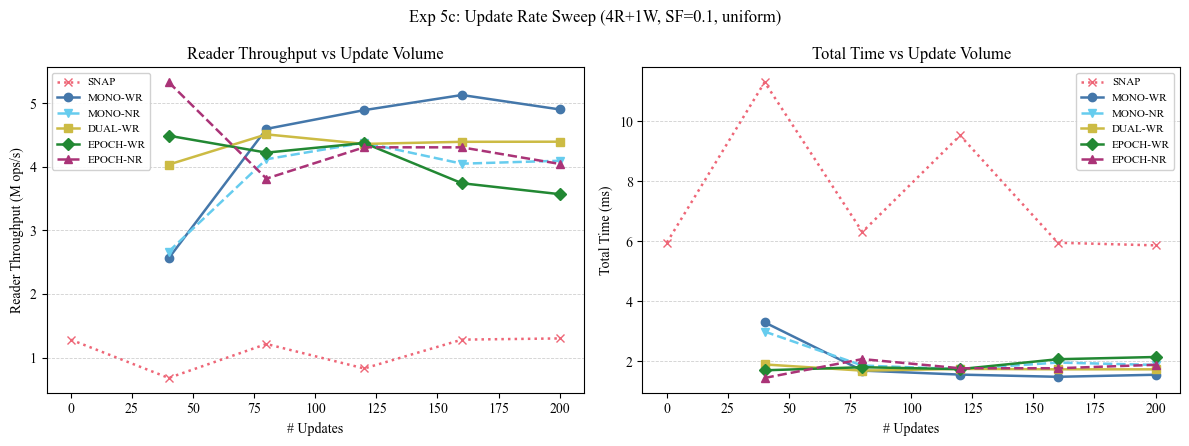

Saved: ./benches/exp5_ivm_join/figs/exp5c_update_sweep_sf0.1_uniform.pdf


In [ ]:
# ── Plot 5c: Throughput vs Update Rate ────────────────────────────────────
df5c = pd.read_csv(CSV_5C)
df5c['table']  = df5c['table_type'].map(tmap).fillna(df5c['table_type'])
df5c['repair'] = df5c['repair_mode'].map(rmap).fillna(df5c['repair_mode'])

# Compute update_pct from total_updates / total_probes if not in CSV
# We know the mapping from the sweep
# For now, group by (table, repair, total_updates) and use total_updates as x-axis proxy

LINES_5C = [
    ('snap',  'NR', 'SNAP',     tol['red'],    ':',  'x'),
    ('heap',  'WR', 'MONO-WR',  tol['blue'],   '-',  'o'),
    ('heap',  'NR', 'MONO-NR',  tol['cyan'],   '--', 'v'),
    ('chain', 'WR', 'DUAL-WR',  tol['yellow'], '-',  's'),
    ('par',   'WR', 'EPOCH-WR', tol['green'],  '-',  'D'),
    ('par',   'NR', 'EPOCH-NR', tol['purple'], '--', '^'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for (t, r, label, color, ls, marker) in LINES_5C:
    rows = df5c[(df5c['table'] == t) & (df5c['repair'] == r)].sort_values('total_updates')
    if rows.empty:
        continue
    ax1.plot(rows['total_updates'], rows['reader_throughput'] / 1e6,
             label=label, color=color, linestyle=ls, marker=marker,
             linewidth=1.8, markersize=6)
    ax2.plot(rows['total_updates'], rows['total_ms'],
             label=label, color=color, linestyle=ls, marker=marker,
             linewidth=1.8, markersize=6)

ax1.set_xlabel('# Updates')
ax1.set_ylabel('Reader Throughput (M ops/s)')
ax1.set_title('Reader Throughput vs Update Volume')
ax1.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax1.legend(framealpha=0.9, fontsize=8)

ax2.set_xlabel('# Updates')
ax2.set_ylabel('Total Time (ms)')
ax2.set_title('Total Time vs Update Volume')
ax2.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax2.legend(framealpha=0.9, fontsize=8)

fig.suptitle(f'Exp 5c: Update Rate Sweep ({READERS_5C}R+{WRITERS_5C}W, SF={SF}, {DIST})', fontsize=12)
plt.tight_layout()
out_pdf = EXP5_DIR / 'figs' / f'exp5c_update_sweep_sf{SF}_{DIST}.pdf'
plt.savefig(str(out_pdf), format='pdf')
plt.show()
print('Saved:', out_pdf)